In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

# Product Sales Analysis Dashboard

## Business Problem

The objective of this project is to analyze product sales performance, identify top-selling products, evaluate regional sales trends, understand customer purchasing behavior, and provide business recommendations for revenue growth.

## Tools Used

- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib

In [24]:
# Create DataFrame
data = pd.read_excel(r"C:\Users\Poonam\OneDrive\Desktop\Poonam Data Analysis\Project\Product Sales Analytics\Product Sales.xlsx")
df = pd.DataFrame(data)

In [25]:
# Check Data Types, Columns Name. 
df.describe()
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1500 non-null   datetime64[ns]
 1   Region         1500 non-null   object        
 2   Product        1500 non-null   object        
 3   Quantity       1500 non-null   int64         
 4   UnitPrice      1500 non-null   float64       
 5   StoreLocation  1500 non-null   object        
 6   CustomerType   1500 non-null   object        
 7   Discount       1500 non-null   float64       
 8   Salesperson    1500 non-null   object        
 9   TotalPrice     1500 non-null   float64       
 10  PaymentMethod  1500 non-null   object        
 11  Promotion      1130 non-null   object        
 12  Returned       1500 non-null   int64         
 13  OrderID        1500 non-null   object        
 14  CustomerName   1500 non-null   object        
 15  ShippingCost   1500 n

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,FREESHIP,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,SAVE10,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,WINTER15,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,FREESHIP,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,SAVE10,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [26]:
df.isnull().sum()

# Find Null Values and replace with NA
df['Promotion'].fillna('NA', inplace= True)

## Data Quality Check

The dataset was checked for missing values and data type consistency before performing analysis.

In [27]:
# Change Data type from float to integer
columns = ['UnitPrice', 'Discount', 'TotalPrice', 'ShippingCost']
df[columns] = df[columns].astype(int)
df.dtypes()

TypeError: 'Series' object is not callable

In [ ]:
# Change Order Date Format
df['Order_Date'] = pd.to_datetime(df['OrderDate'])
print(df['Order_Date'])
df['TotalPrice'] = df['Quantity']*df['UnitPrice']
df['TotalPrice']

0      2023-02-23
1      2024-12-19
2      2023-05-10
3      2025-02-26
4      2023-06-24
          ...    
1495   2025-02-17
1496   2024-01-11
1497   2024-07-27
1498   2024-12-03
1499   2025-05-09
Name: Order_Date, Length: 1500, dtype: datetime64[ns]
0       2282
1        544
2       4844
3       6912
4       4266
        ... 
1495    1742
1496    3762
1497     272
1498    3668
1499    2873
Name: TotalPrice, Length: 1500, dtype: int64


In [ ]:
# Product Wise Sales / Best Selling Product
Best_Product = df.groupby("Product")['TotalPrice'].sum()
print("Best Selling Product : ", "Product", Best_Product)

Best Selling Product :  Product Product
Chair      668363
Desk       601028
Laptop     735897
Monitor    702610
Phone      535710
Printer    742346
Tablet     734354
Name: TotalPrice, dtype: int64


## Key Insight

A small number of products generate the majority of total revenue.

These products should be prioritized for inventory planning, promotions, and sales forecasting.

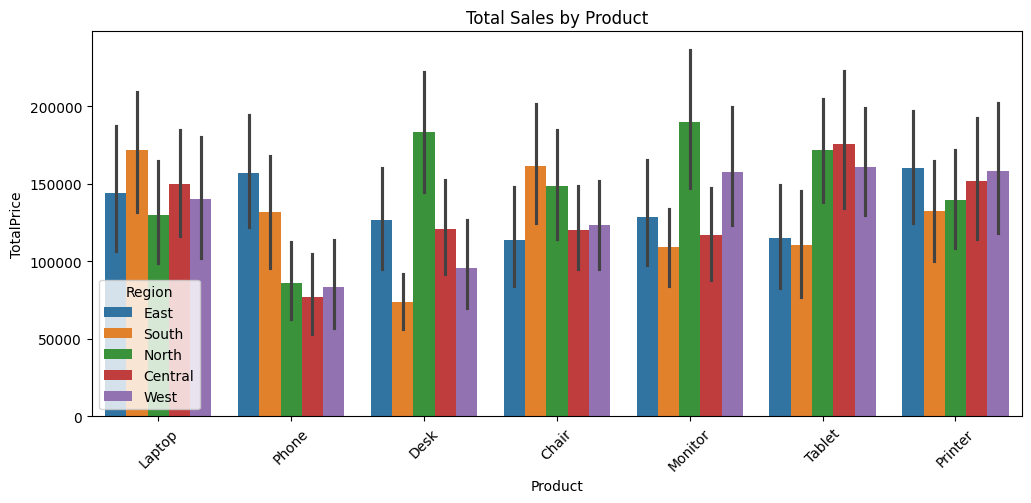

In [ ]:
# Show Best Selling Product using Bar Plot
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="Product", y="TotalPrice", hue = "Region", estimator=sum)
plt.title("Total Sales by Product")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Month Wise Sale
df["Month"] = df['OrderDate'].dt.month
print(df["Month"])
Monthly_Sale = df.groupby("Month")['TotalPrice'].sum().sort_values(ascending=False)
print("Monthly Sale : ", "Month", Monthly_Sale)

0        2
1       12
2        5
3        2
4        6
        ..
1495     2
1496     1
1497     7
1498    12
1499     5
Name: Month, Length: 1500, dtype: int32
Monthly Sale :  Month Month
3     579479
1     531532
4     476504
6     468442
2     450192
5     436024
8     311873
11    303597
9     302714
7     301388
12    281509
10    277054
Name: TotalPrice, dtype: int64


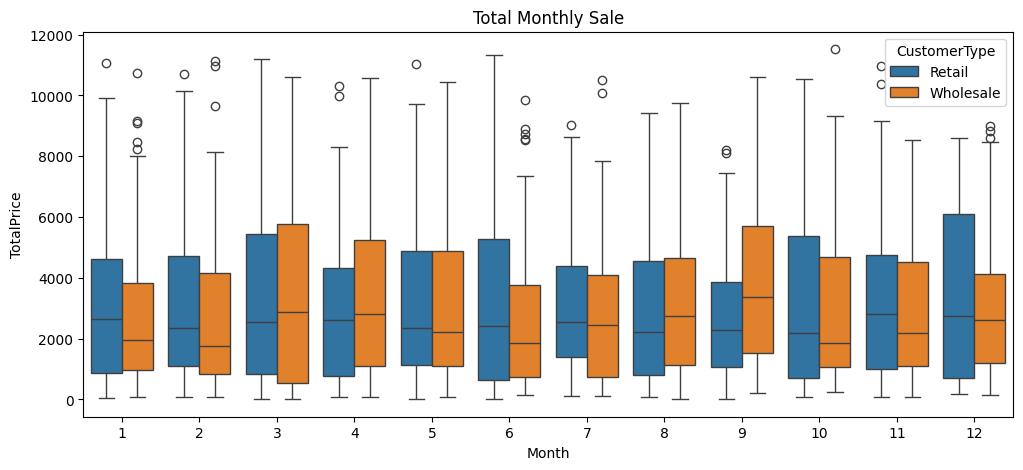

In [ ]:
# Monthly Sale by using Line Plot
plt.figure(figsize=(12,5))

sns.lineplot(
    data=df,
    x='Month',
    y='TotalPrice',
    estimator='sum',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.show()

## Key Insight

Sales vary across different months, indicating seasonal demand patterns.

Peak sales periods should be considered while planning inventory and marketing campaigns.

In [ ]:
# Region Wise Sale
Region_Sale = df.groupby('Region')['TotalPrice'].sum().sort_values(ascending=False)
print("Region Wise Sale : ", "Region", Region_Sale)

Region Wise Sale :  Region Region
North      1049398
East        945833
West        920030
Central     913351
South       891696
Name: TotalPrice, dtype: int64


## Key Insight

Certain regions contribute significantly more revenue than others.

High-performing regions should receive additional marketing investment while underperforming regions require growth strategies.

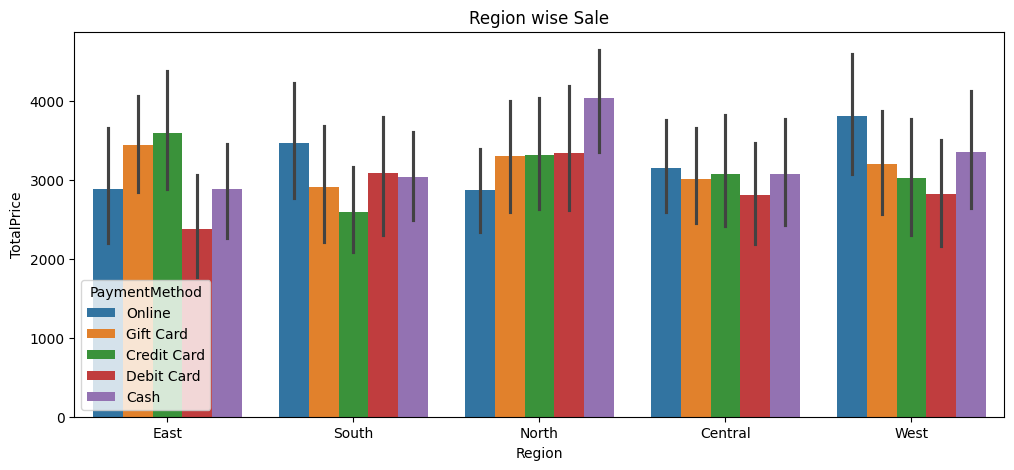

In [ ]:
# Show Region wise sale by using Bar plot
plt.figure(figsize=(12,5))
sns.barplot(data=df, x=df["Region"], y="TotalPrice", hue="PaymentMethod")
plt.title("Region wise Sale")
plt.show()

In [33]:
# Top Sale Person
Best_SalePerson = df.groupby('Salesperson')['TotalPrice'].sum().sort_values(ascending=False)
print("Best Top Sales Person : ", "Region", "Salesperson", Best_SalePerson)

Best Top Sales Person :  Region Salesperson Salesperson
Bob       796667
Alice     786039
Frank     714522
Carlos    707042
Eva       698553
Diana     676447
Name: TotalPrice, dtype: int64


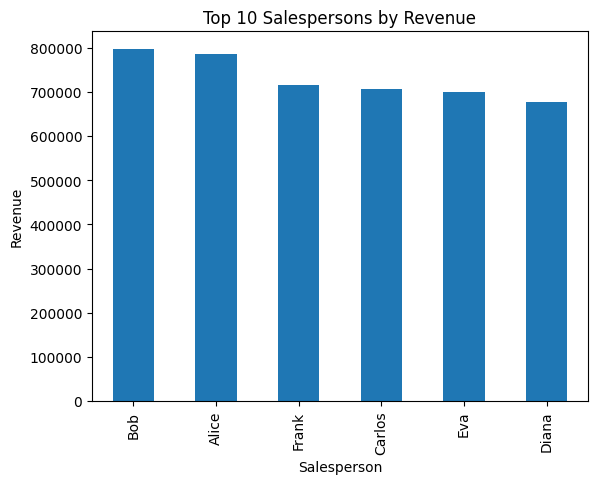

In [34]:
# Show sales person contribution by using Bar plot.

Best_SalePerson.head(10).plot(kind='bar')

plt.title('Top 10 Salespersons by Revenue')
plt.ylabel('Revenue')

plt.show()

## Key Insight

Top-performing salespersons contribute a significant share of overall revenue.

Their sales strategies can be replicated across the team to improve performance.

In [ ]:
# Store / Location Wise Sale
Sales_By_Store = df.groupby('StoreLocation')['TotalPrice'].sum().sort_values(ascending=False)
print("Store / Location Sale Amount : ", "StoreLocation", Sales_By_Store)

Store / Location Sale Amount :  StoreLocation StoreLocation
Store D    1301674
Store A    1170436
Store C    1137641
Store B    1110557
Name: TotalPrice, dtype: int64


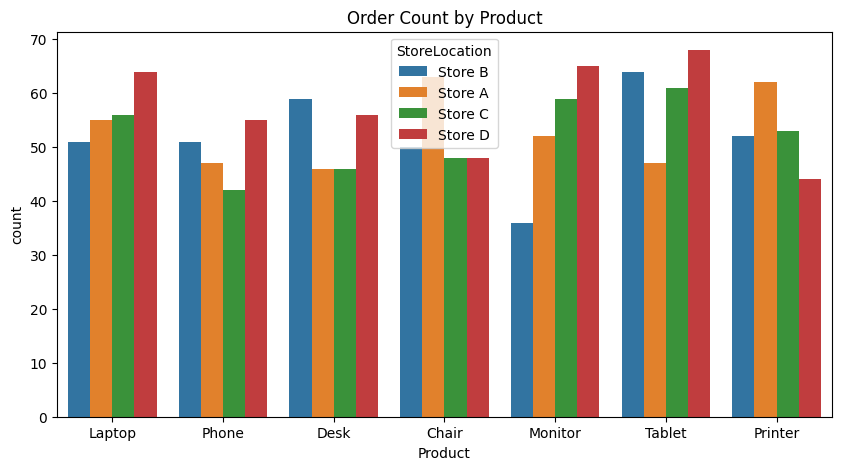

In [ ]:
#Order Count by Product by using Bar Plot on Store Basis
Sales_By_Store.plot(kind='bar')

plt.title('Sales by Store Location')

plt.show()

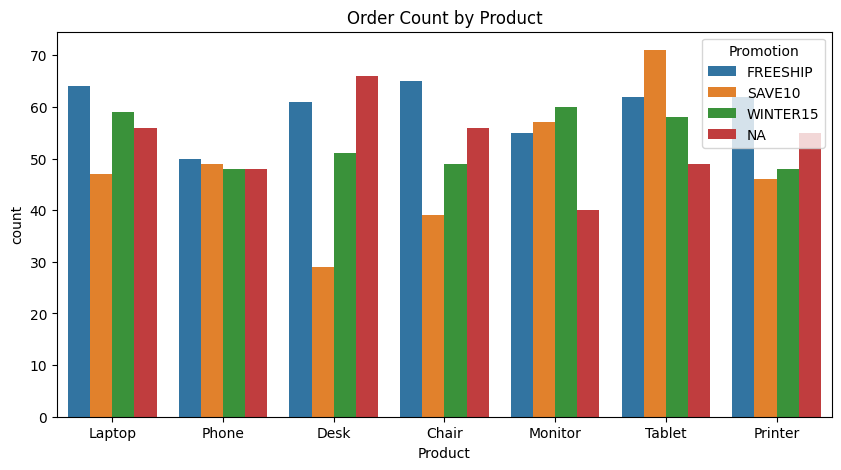

In [ ]:
#Order Count by Product by using Count Plot  on Promotion basis
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Product', hue="Promotion")
plt.title("Order Count by Product")
plt.show()

In [35]:
# Most Used Payment Option
Most_Used_Payment_Method = df.groupby("PaymentMethod")['TotalPrice'].sum().sort_values(ascending=False) 
print("Mostly used Payment Option : ", "PaymentMethod", Most_Used_Payment_Method)

Mostly used Payment Option :  PaymentMethod PaymentMethod
Online         970959
Cash           950239
Credit Card    866337
Gift Card      821452
Debit Card     770283
Name: TotalPrice, dtype: int64


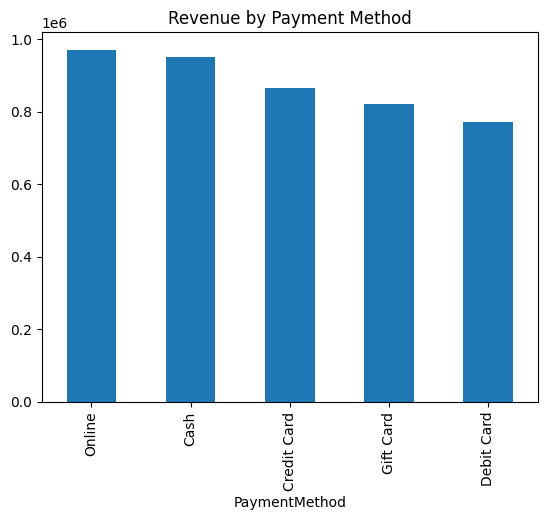

In [43]:
Most_Used_Payment_Method.plot(kind='bar')

plt.title('Revenue by Payment Method')

plt.show()

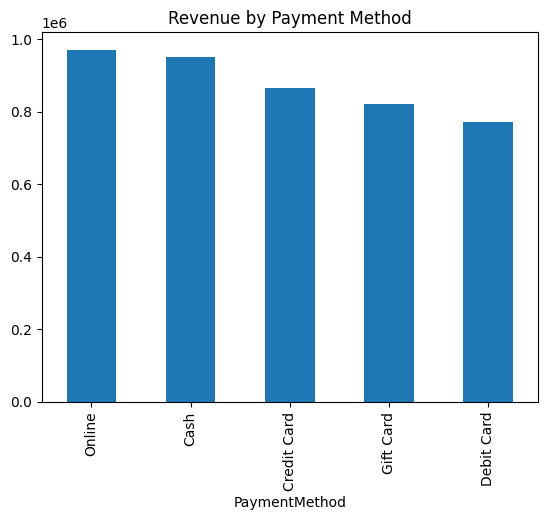

In [45]:
Most_Used_Payment_Method.plot(kind='bar')

plt.title('Revenue by Payment Method')

plt.show()

## Key Insight

Customers show clear payment preferences.

Preferred payment methods should be optimized to improve customer experience and conversion rates.

In [47]:
# Top Customers
Top_Customer = df.groupby("CustomerType")['TotalPrice'].sum().sort_values(ascending=False)
print("Top Customer : ", "CustomerType", Top_Customer)

Top Customer :  CustomerType CustomerType
Retail       2195170
Wholesale    2184100
Name: TotalPrice, dtype: int64


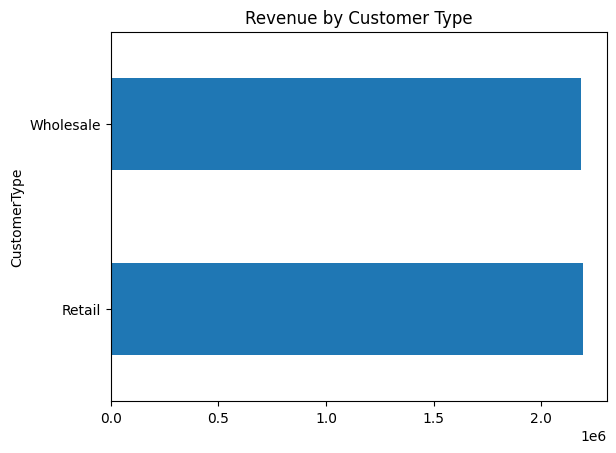

In [51]:
Top_Customer.plot(kind='barh')

plt.title('Revenue by Customer Type')

plt.show()

## Key Insight

Customer segments contribute differently to overall revenue.

High-value customer groups should be targeted through retention and loyalty initiatives.

In [ ]:
# Returned Product amount
Returned_Customer = df.groupby("Returned")['TotalPrice'].sum().reset_index()
print("Returned Product Cost : ", "Product ",  Returned_Customer)

Returned Product Cost :  Product  <bound method Series.nlargest of Returned
0    3522835
1    1197473
Name: TotalPrice, dtype: int64>


In [65]:
plt.figure(figsize=(11,5))
sns.barplot(data= r"Returned_Customer",  x='Returned', y='TotalPrice')

plt.title('Returned Product Cost')

plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'str'>.

<Figure size 1100x500 with 0 Axes>

## Key Insight

Returned products represent lost revenue and operational cost.

Return patterns should be analyzed to identify quality or fulfillment issues.

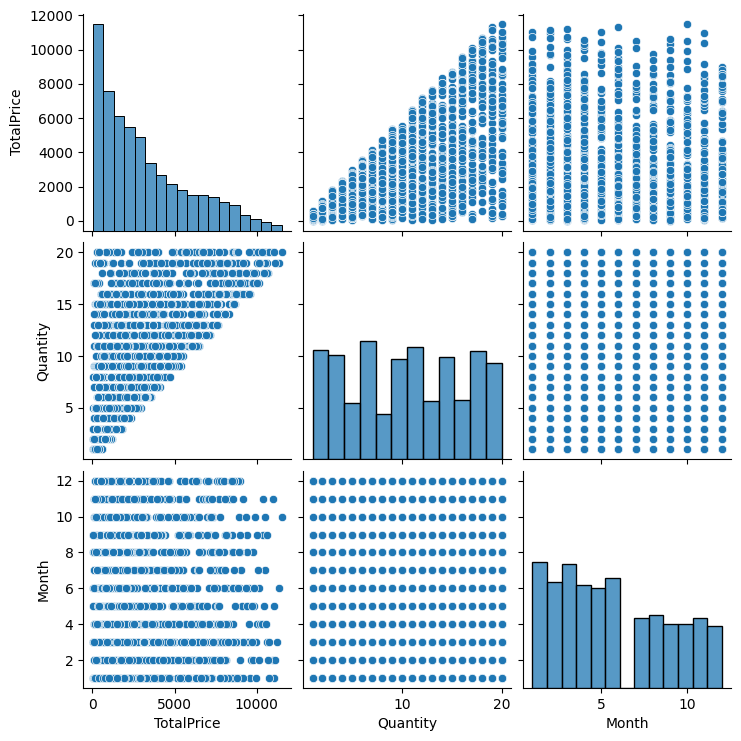

In [ ]:
# Relationship between Columns
corr = df[['TotalPrice','Quantity','UnitPrice','Discount']].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

## Key Insight

Strong relationships between sales metrics help identify factors driving revenue performance.

# Final Business Insights

1. A few products contribute the majority of sales revenue.

2. Sales exhibit seasonal patterns across months.

3. Regional performance varies significantly.

4. Customer segments show different purchasing behaviors.

5. Product returns impact profitability.

# Business Recommendations

- Focus inventory on top-selling products.
- Prepare for seasonal demand spikes.
- Increase marketing efforts in high-performing regions.
- Improve retention programs for valuable customers.
- Reduce product return rates through quality monitoring.